In [1]:
%load_ext autoreload
%autoreload 2
import torch
from training_functions import train, evaluate_mae_mse
from TransCrowd import base_patch16_384_token, base_patch16_384_gap
import torch.nn as nn
import torch.optim as optim
from dataloader_mcnn import CrowdDataset
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, ConcatDataset
import glob
import os
import numpy as np
import random
import time
import pandas as pd
from torchvision import transforms
SEED = 42

e:\OneDrive\Pulpit\MSC-thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
e:\OneDrive\Pulpit\MSC-thesis\.venv\Lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
e:\OneDrive\Pulpit\MSC-thesis\.venv\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

In [50]:
main_folders = [r"data\ShanghaiTech_part_A", 
                r"data\ShanghaiTech_part_B"]

train_datasets = []
val_datasets = []


transform = transforms.Compose([
                                transforms.ToTensor(),

                                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                     std=[0.229, 0.224, 0.225]),
                            ])

for folder in main_folders:
    train_img_root = os.path.join(folder, "train", "images")
    train_map_root = os.path.join(folder, "train", "maps")
    print(folder)
    if os.path.exists(train_img_root) and os.path.exists(train_map_root):
        print('ok')
        train_datasets.append(CrowdDataset(train_img_root, train_map_root, gt_downsample=1, resize=False,
                                           transform=transform, patch=True, train=True))
    
    val_img_root = os.path.join(folder, "test", "images")
    val_map_root = os.path.join(folder, "test", "maps")
    
    if os.path.exists(val_img_root) and os.path.exists(val_map_root):
        val_datasets.append(CrowdDataset(val_img_root, val_map_root, gt_downsample=1, resize=False,
                                         transform=transform, patch=True))

train_dataset = ConcatDataset(train_datasets)
val_dataset = ConcatDataset(val_datasets)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False,pin_memory=True)

data\ShanghaiTech_part_A
ok
data\ShanghaiTech_part_B
ok


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.247899..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


torch.Size([6, 3, 384, 384]) 1544.3978
float32
1544.3978
torch.Size([6, 3, 384, 384]) 900.7889
float32
900.7889
torch.Size([6, 3, 384, 384]) 369.70255
float32
369.70255


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..2.64].


torch.Size([6, 3, 384, 384]) 295.6619


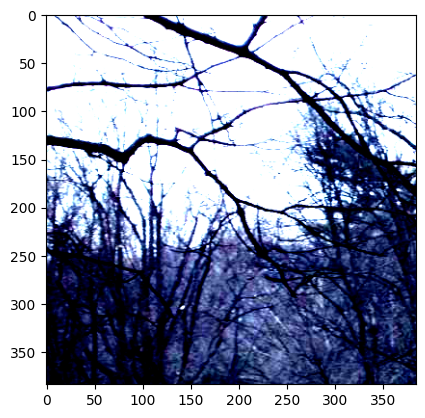

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

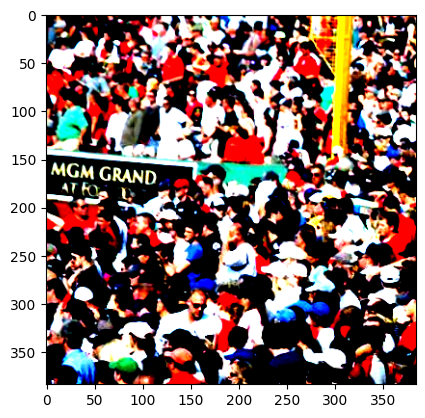

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

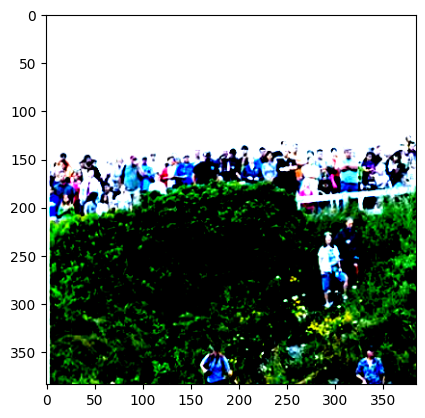

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

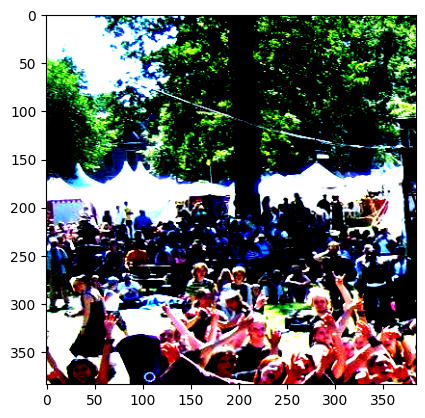

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [48]:
for i,(fname, img,gt_dmap) in enumerate(train_dataset):
    # pred = img.unsqueeze(0)
    # pred = model(pred.to(device)).squeeze(0)
    plt.imshow(img[0].permute(1, 2, 0))
    plt.figure()
    # plt.imshow(gt_dmap.permute(1, 2, 0))
    plt.figure()
    print(img.shape,gt_dmap)
    # plt.imshow(pred.permute(1, 2, 0).cpu().detach().numpy())
    plt.figure()
    if i>2:
        break
    
    print(gt_dmap.dtype)
    print(gt_dmap.sum())
    # print(pred.sum())

In [53]:

set_seed(SEED)
model_dir = r"output\models\transcrowd"
history_dir = r"output\history\transcrowd"

os.makedirs(model_dir, exist_ok=True)
os.makedirs(history_dir, exist_ok=True)

model_path = model_dir + "/transcrowd.pth"
history_path = history_dir + "/transcrowd.pkl"

device = "cuda" if torch.cuda.is_available() else "cpu"
model = base_patch16_384_gap(pretrained=True)
model = model.to(device)
epochs = 100
tolerance = 20
print(device)
criterion = nn.L1Loss(reduction='mean').to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)


start_time = time.time()
history = train(epochs, model, train_loader, val_loader, optimizer, criterion, device,model_path, tolerance = tolerance, is_dmap=False)
end_time = time.time()
print(f"total time: {end_time - start_time}\n")


load transformer pretrained
cpu


KeyboardInterrupt: 

In [2]:
df2 = pd.read_csv(r'output\history\transcrowd\evaluation_extended.csv')
df2 = df2[df2['gt'] != 0]
df2.groupby('dataset').mean()

,Unnamed: 0,pred,gt,diff,abs_err,perc
dataset,,,,,,
NWPU-Crowd,743.675269,301.483981,418.947282,-117.463301,193.188832,0.896770
ShanghaiTech_part_A,90.500000,414.198844,428.208560,-14.009716,77.236668,0.192573
ShanghaiTech_part_B,339.500000,115.919112,118.925279,-3.006167,12.846979,0.123859
UCF-QNRF_ECCV18,1164.500000,529.319680,713.306541,-183.986861,235.015273,0.273297
jhu_crowd_v2.0,2131.270050,315.366838,323.575243,-8.208406,153.916562,2.651895
ucf-cc-50,2956.500000,980.510931,1272.469128,-291.958196,447.704449,0.336074


Text(0, 0.5, 'Difference')

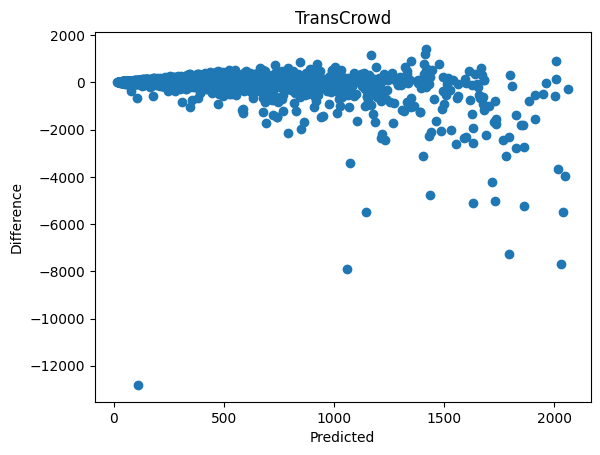

In [5]:
plt.scatter(df2['pred'], df2['diff'])
plt.title('TransCrowd')
plt.xlabel('Predicted')
plt.ylabel('Difference')

Text(0, 0.5, 'Predicted')

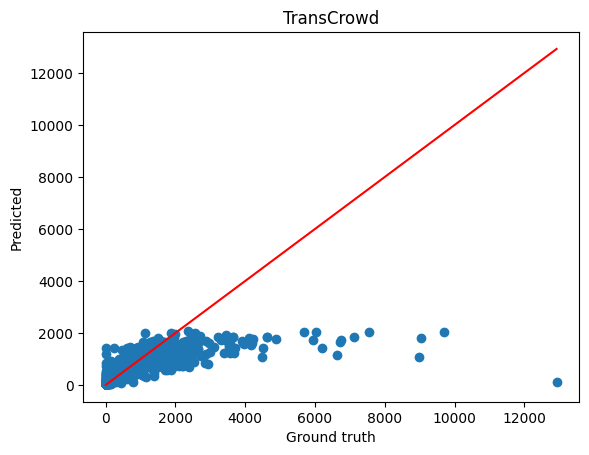

In [6]:
plt.scatter(df2['gt'], df2['pred'])
plt.plot([0,max(df2['gt'])], [0, max(df2['gt'])], color='red')
plt.title('TransCrowd')
plt.xlabel('Ground truth')
plt.ylabel('Predicted')

In [34]:
df2 = pd.read_csv(r'output\history\transcrowd\evaluation_extended.csv')
df2 = df2[df2['gt'] == 0]


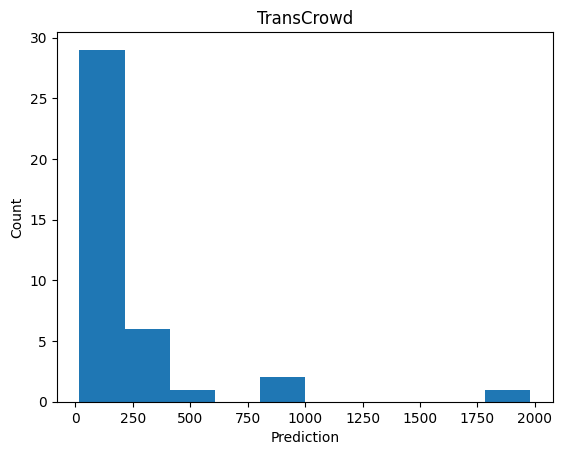

In [38]:
plt.hist(df2['pred'])
plt.xlabel("Prediction")
plt.ylabel("Count")
plt.title('TransCrowd')
plt.show()

In [14]:
def bins(x):
    if x <= 50:
        return 'small'
    if x <= 200:
        return 'medium'
    if x <= 1000:
        return 'high'
    else:
        return 'large'

In [18]:
df2 = pd.read_csv(r'output\history\transcrowd\evaluation_extended.csv')
df2 = df2[df2['gt'] != 0]
df2['bins'] = df2['gt'].apply(lambda x: bins(x))
df2['rmse'] = (df2['pred'] - df2['gt'])**2
df2.drop(columns='dataset', inplace=True)
df2 = df2.groupby(['bins']).mean()
df2['rmse'] = df2['rmse']**(1/2)
df2

,Unnamed: 0,pred,gt,diff,abs_err,perc,rmse
bins,,,,,,,
high,1376.074262,453.452352,434.604647,18.847705,110.235406,0.260080,167.254954
large,1609.323077,1209.643432,2149.580432,-939.937000,989.715743,0.356928,1750.853165
medium,1458.670909,157.892203,114.706792,43.185410,52.187272,0.498299,92.903736
small,1720.323333,79.026826,27.223350,51.803477,52.311975,6.558510,120.977368


In [30]:
df2 = pd.read_csv(r'output\history\transcrowd\evaluation_extended.csv')
df2 = df2[df2['gt'] != 0]
df2['bins'] = df2['gt'].apply(lambda x: (x//100 + 1)*100)
df2['rmse'] = (df2['pred'] - df2['gt'])**2
df2.drop(columns='dataset', inplace=True)